In [13]:
import numpy as np
import pandas as pd
from sympy import limit
import wandb

api = wandb.Api(
    api_key="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"
)

# 1. Get last 10 runs (sorted by creation time descending)
runs = api.runs(
    "eibl-usc/graph-clip",
    filters={
        # "display_name": {"$regex": "trained_on_.._eval_on_.._..?_shot_.+"},
        # "config.dataset": "ukr_rus_twitter",
        # "config.task_name": "neighbor_matching",
    },
    order="-created_at",
    per_page=10,
    # limit to 10:
    lazy=False
)

In [61]:
rows = []
for run in runs[:250]:
    attrs = getattr(run, "_attrs", {}) or {}
    params = ((attrs.get("config") or {}).get("params") or {})
    summary = attrs.get("summaryMetrics") or {}

    rows.append({
        "run_id": attrs.get("name"),
        "display_name": attrs.get("displayName"),
        "state": attrs.get("state"),
        "dataset": params.get("dataset"),
        "task_name": params.get("task_name"),
        "prefix": params.get("prefix"),
        "pretrained_model_run": params.get("pretrained_model_run"),
        "n_shots": params.get("n_shots"),
        "n_way": params.get("n_way"),
        "n_query": params.get("n_query"),
        "zero_shot": params.get("zero_shot"),
        "test_accuracy": summary.get("test_accuracy"),
        "test_f1": summary.get("test_f1"),
        "test_roc_auc": summary.get("test_roc_auc"),
    })
df = pd.DataFrame(rows)
df["train1_dataset"] = df["pretrained_model_run"].str.extract(r"train1_(covid19_twitter|midterm|ukr_rus_twitter)_")
df["train1_task"] = df["pretrained_model_run"].str.extract(r"train1_.+?_(nm|pl|lp)_")
df["eval1_task"] = df["task_name"].map({
    "neighbor_matching": "nm",
    "temporal_link_prediction": "lp",
    "classification": "pl",
})
df["shot_label"] = df.apply(lambda r: 0 if bool(r.get("zero_shot", False)) else r["n_shots"], axis=1)
# plot_df = df[df["eval1_task"].isin(EVAL_TASKS) & df["train1_task"].eq("nm")].copy()
df['eval1_dataset'] = df['dataset']

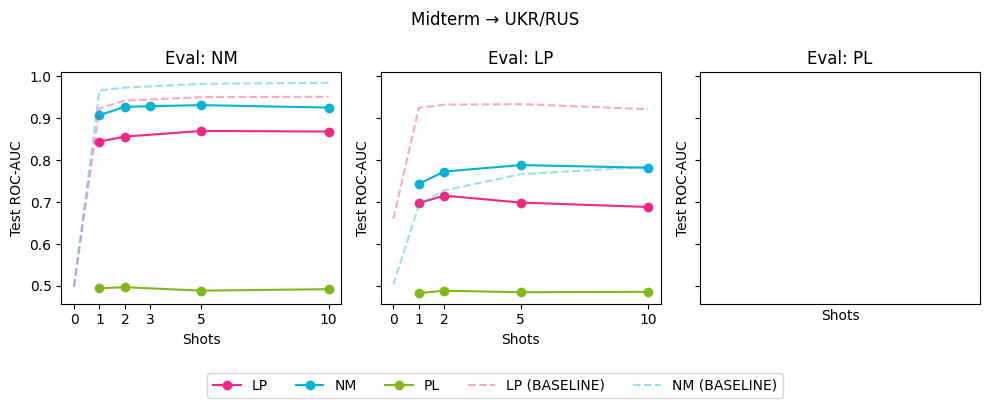

In [59]:
import matplotlib.pyplot as plt

colors = {
    "nm": "#00b4d8",
    "lp": "#f72585",
    "pl": "#80b918"
}
EVAL_TASKS = ["nm", "lp", "pl"]

# --- Data ---
i_cross = df.train1_dataset.eq('midterm') & df.eval1_dataset.eq('ukr_rus_twitter')
plot_df_cross = df[i_cross].copy()

i_same = df.train1_dataset.eq('covid19_twitter') & df.eval1_dataset.eq('covid19_twitter') & df.prefix.str.startswith("trained")
plot_df_same = df[i_same].dropna()

# --- Plot ---
fig, axes = plt.subplots(1, len(EVAL_TASKS), figsize=(10, 4), sharey=True)
if len(EVAL_TASKS) == 1:
    axes = [axes]

for ax, eval_task in zip(axes, EVAL_TASKS):
    # Cross-dataset lines (solid)
    subset_cross = plot_df_cross[plot_df_cross["eval1_task"] == eval_task]
    for train_task in sorted(subset_cross["train1_task"].dropna().unique()):
        sub = subset_cross[subset_cross["train1_task"] == train_task].sort_values("shot_label")
        ax.plot(sub["shot_label"], sub["test_roc_auc"],
                marker="o", label=f"{train_task}",
                color=colors.get(train_task), linestyle="-")

    # Same-dataset baseline lines (dashed)
    subset_same = plot_df_same[plot_df_same["eval1_task"] == eval_task]
    for train_task in sorted(subset_same["train1_task"].dropna().unique()):
        sub = subset_same[subset_same["train1_task"] == train_task].sort_values("shot_label")
        ax.plot(sub["shot_label"], sub["test_roc_auc"],
                marker="", label=f"{train_task} (baseline)",
                color=colors.get(train_task), linestyle="--", alpha=0.4)

    ax.set_title(f"Eval: {eval_task.upper()}")
    ax.set_xlabel("Shots")
    ax.set_ylabel("Test ROC-AUC")
    all_shots = pd.concat([subset_cross, subset_same])["shot_label"].dropna().unique()
    ax.set_xticks(sorted(all_shots))

handles, labels = axes[0].get_legend_handles_labels()
labels = [x.upper() for x in labels]
if handles:
    fig.legend(handles, labels, loc="lower center", ncol=max(1, len(labels)))

fig.suptitle("Midterm → UKR/RUS")
plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()

In [64]:
models = plot_df_cross.pretrained_model_run.value_counts().index.str.split('/').str[1]
df[df.display_name.isin(models)][['display_name', 'dataset', 'task_name', 'n_way', 'n_shots', 'n_query']].to_clipboard()

models = plot_df_same.pretrained_model_run.value_counts().index.str.split('/').str[1]
df[df.display_name.isin(models)][['display_name', 'dataset', 'task_name', 'n_way', 'n_shots', 'n_query']].to_clipboard()

In [79]:
df[df.train1_dataset == df.eval1_dataset]

,run_id,display_name,state,dataset,task_name,prefix,pretrained_model_run,n_shots,n_way,n_query,zero_shot,test_accuracy,test_f1,test_roc_auc,train1_dataset,train1_task,eval1_task,shot_label,eval1_dataset
0,jj90hkal,trained_on_lp_eval_on_lp_10_shot_03_04_2026_09...,finished,covid19_twitter,temporal_link_prediction,trained_on_lp_eval_on_lp_10_shot,state/train1_covid19_twitter_lp_02_04_2026_17_...,10,1,3,False,0.758000,0.701775,0.921503,covid19_twitter,lp,lp,10,covid19_twitter
1,sntq03aw,trained_on_lp_eval_on_nm_10_shot_03_04_2026_09...,finished,covid19_twitter,neighbor_matching,trained_on_lp_eval_on_nm_10_shot,state/train1_covid19_twitter_lp_02_04_2026_17_...,10,2,8,False,0.870075,0.871689,0.951239,covid19_twitter,lp,nm,10,covid19_twitter
2,qcf23efo,trained_on_lp_eval_on_lp_5_shot_03_04_2026_09_...,finished,covid19_twitter,temporal_link_prediction,trained_on_lp_eval_on_lp_5_shot,state/train1_covid19_twitter_lp_02_04_2026_17_...,5,1,3,False,0.833867,0.820409,0.933751,covid19_twitter,lp,lp,5,covid19_twitter
3,lqkcj03l,trained_on_lp_eval_on_nm_5_shot_03_04_2026_09_...,finished,covid19_twitter,neighbor_matching,trained_on_lp_eval_on_nm_5_shot,state/train1_covid19_twitter_lp_02_04_2026_17_...,5,2,8,False,0.870200,0.871600,0.950391,covid19_twitter,lp,nm,5,covid19_twitter
4,fqt0yf26,trained_on_lp_eval_on_lp_2_shot_03_04_2026_09_...,finished,covid19_twitter,temporal_link_prediction,trained_on_lp_eval_on_lp_2_shot,state/train1_covid19_twitter_lp_02_04_2026_17_...,2,1,3,False,0.856800,0.856340,0.932386,covid19_twitter,lp,lp,2,covid19_twitter
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,x6wima29,eval_lp_on_lp_27_03_2026_15_50_35,finished,midterm,temporal_link_prediction,eval_lp_on_lp,state/train1_midterm_lp_24_03_2026_12_11_22/ch...,1,1,3,False,0.893067,0.897573,0.954082,midterm,lp,lp,1,midterm
246,ag2pk2i6,eval_lp_on_nm_27_03_2026_15_46_44,finished,midterm,neighbor_matching,eval_lp_on_nm,state/train1_midterm_lp_24_03_2026_12_11_22/ch...,3,3,24,False,0.666694,0.665783,0.873535,midterm,lp,nm,3,midterm
247,866x5pgl,eval_nm_on_pl_27_03_2026_15_46_13,finished,midterm,classification,eval_nm_on_pl,state/train1_midterm_nm_24_03_2026_12_15_40/ch...,4,2,3,False,0.952200,0.952400,0.975645,midterm,nm,pl,4,midterm
248,xbmxk230,eval_nm_on_lp_27_03_2026_15_45_36,finished,midterm,temporal_link_prediction,eval_nm_on_lp,state/train1_midterm_nm_24_03_2026_12_15_40/ch...,1,1,3,False,0.688533,0.761023,0.866713,midterm,nm,lp,1,midterm


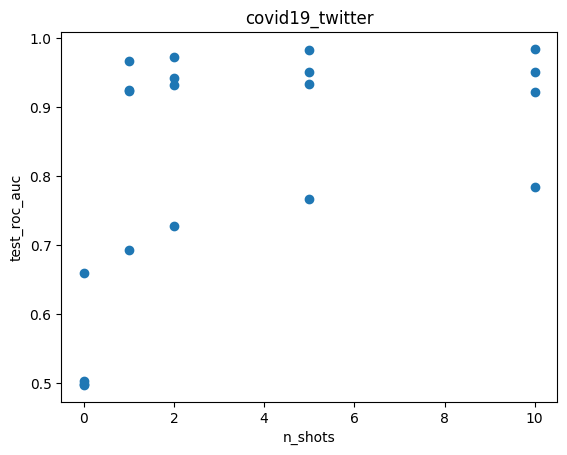

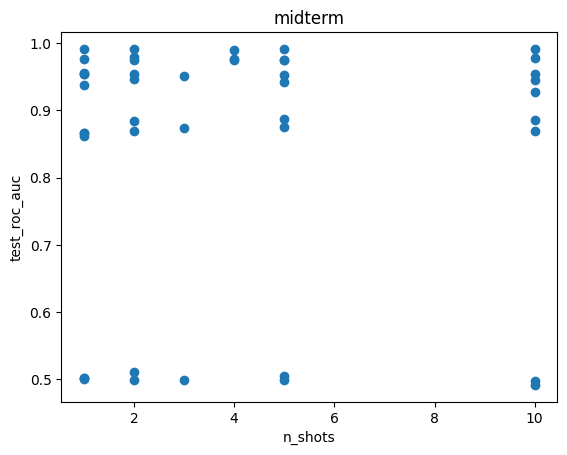

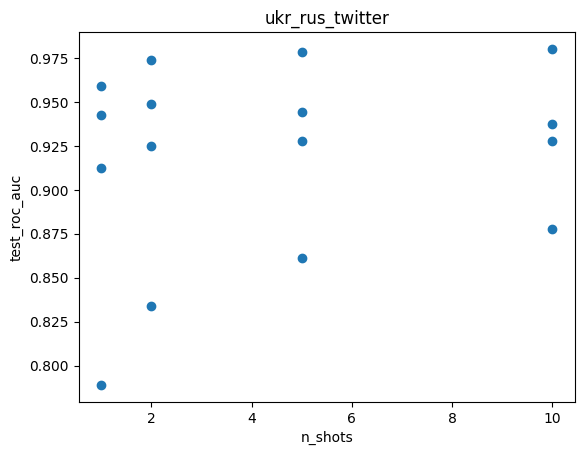

In [ ]:
import matplotlib.pyplot as plt

for name, group in df[df.train1_dataset == df.eval1_dataset].groupby('eval1_dataset'):
    plt.figure()
    plt.plot(group['n_shots'], group['test_roc_auc'], marker='o', linestyle='', label=group[])
    plt.title(name)
    plt.xlabel('n_shots')
    plt.ylabel('test_roc_auc')
    plt.show()

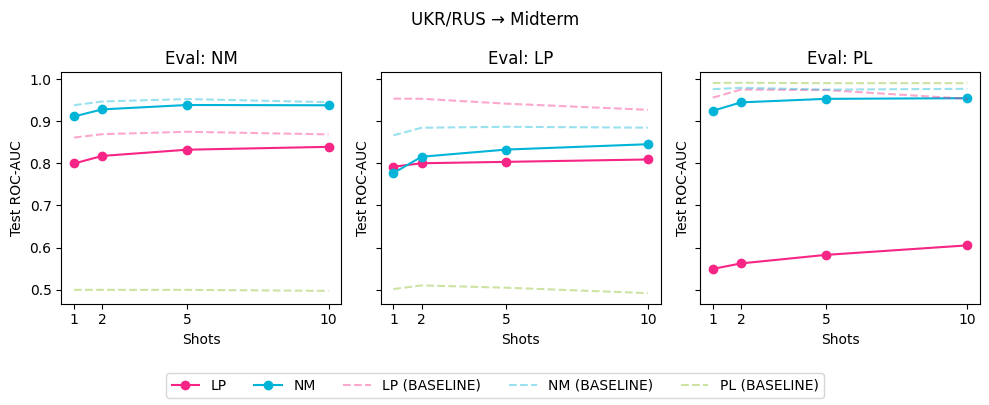

In [58]:
import matplotlib.pyplot as plt

colors = {
    "nm": "#00b4d8",
    "lp": "#f72585",
    "pl": "#80b918"
}
EVAL_TASKS = ["nm", "lp", "pl"]

# --- Data ---
i_cross = df.train1_dataset.eq('ukr_rus_twitter') & df.eval1_dataset.eq('midterm')
plot_df_cross = df[i_cross].copy()

i_same = df.train1_dataset.eq('midterm') & df.eval1_dataset.eq('midterm') & df.prefix.str.startswith("trained")
plot_df_same = df[i_same].dropna()

# --- Plot ---
fig, axes = plt.subplots(1, len(EVAL_TASKS), figsize=(10, 4), sharey=True)
if len(EVAL_TASKS) == 1:
    axes = [axes]

for ax, eval_task in zip(axes, EVAL_TASKS):
    # Cross-dataset lines (solid)
    subset_cross = plot_df_cross[plot_df_cross["eval1_task"] == eval_task]
    for train_task in sorted(subset_cross["train1_task"].dropna().unique()):
        sub = subset_cross[subset_cross["train1_task"] == train_task].sort_values("shot_label")
        ax.plot(sub["shot_label"], sub["test_roc_auc"],
                marker="o", label=f"{train_task}",
                color=colors.get(train_task), linestyle="-")

    # Same-dataset baseline lines (dashed)
    subset_same = plot_df_same[plot_df_same["eval1_task"] == eval_task]
    for train_task in sorted(subset_same["train1_task"].dropna().unique()):
        sub = subset_same[subset_same["train1_task"] == train_task].sort_values("shot_label")
        ax.plot(sub["shot_label"], sub["test_roc_auc"],
                marker="", label=f"{train_task} (baseline)",
                color=colors.get(train_task), linestyle="--", alpha=0.4)

    ax.set_title(f"Eval: {eval_task.upper()}")
    ax.set_xlabel("Shots")
    ax.set_ylabel("Test ROC-AUC")
    all_shots = pd.concat([subset_cross, subset_same])["shot_label"].dropna().unique()
    ax.set_xticks(sorted(all_shots))

handles, labels = axes[0].get_legend_handles_labels()
labels = [x.upper() for x in labels]
if handles:
    fig.legend(handles, labels, loc="lower center", ncol=max(1, len(labels)))

fig.suptitle("UKR/RUS → Midterm")
plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()

In [ ]:
models = plot_df_cross.pretrained_model_run.value_counts().index.str.split('/').str[1]
df[df.display_name.isin(models)][['display_name', 'dataset', 'task_name', 'n_way', 'n_shots', 'n_query']].to_clipboard()

models = plot_df_same.pretrained_model_run.value_counts().index.str.split('/').str[1]
df[df.display_name.isin(models)][['display_name', 'dataset', 'task_name', 'n_way', 'n_shots', 'n_query']].to_clipboard()